In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/individual/master_data_12k.csv', usecols=["global_id", "team", "sequence"])

df["team"] = df["team"].apply(lambda x: x.replace(" ", "_"))
with open('../data/individual/12k_binders_teams.fa', 'w') as f:
    for _, row in df.iterrows():
        f.write(f">{row['global_id']}|{row['team']}\n{row['sequence']}\n")

In [2]:
# Convert sequences to a NumPy array of shape (N, L)
seqs = np.array([list(s) for s in df["sequence"]])
N, L = seqs.shape

# Encode as uint8 (faster for comparisons)
seqs_encoded = np.array([list(s.encode("ascii")) for s in df["sequence"]], dtype=np.uint8)

# Pairwise identities (Hamming similarity)
ident_mat = (seqs_encoded[:, None, :] == seqs_encoded[None, :, :]).mean(axis=2)

# Zero out self-comparisons
np.fill_diagonal(ident_mat, 0.0)

# --- WITHIN-TEAM AND CROSS-TEAM ---
groups = df["team"].to_numpy()

within_mask = groups[:, None] == groups[None, :]
cross_mask = groups[:, None] != groups[None, :]

ident_within = np.where(within_mask, ident_mat, 0.0)
ident_cross = np.where(cross_mask, ident_mat, 0.0)

max_pident_within = ident_within.max(axis=1)
max_pident_cross = ident_cross.max(axis=1)

# --- OUTPUT ---
df["max_pident_within_team"] = max_pident_within
df["max_pident_cross_team"] = max_pident_cross
df.to_csv('../data/individual/max_pairwise_identities_hamming.csv', index=False)

KeyboardInterrupt: 

Hamming identity:
Within-team max:   0.9875
Within-team min:   0.0875
Within-team mean:  0.6891531249999999
Within-team median:0.7375
Cross-team max:    0.65
Cross-team min:    0.1375
Cross-team mean:   0.2724947916666667
Cross-team median: 0.275


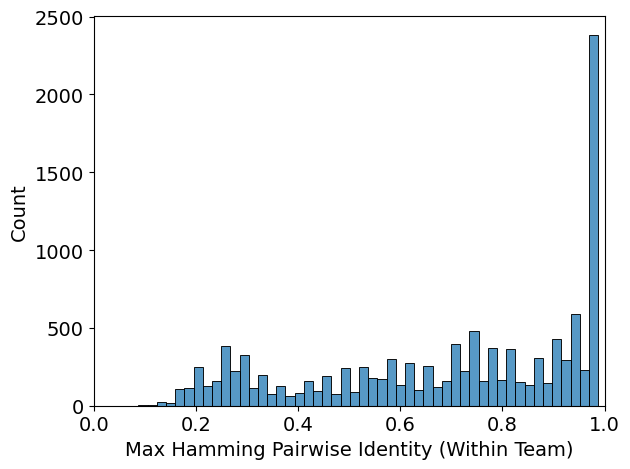

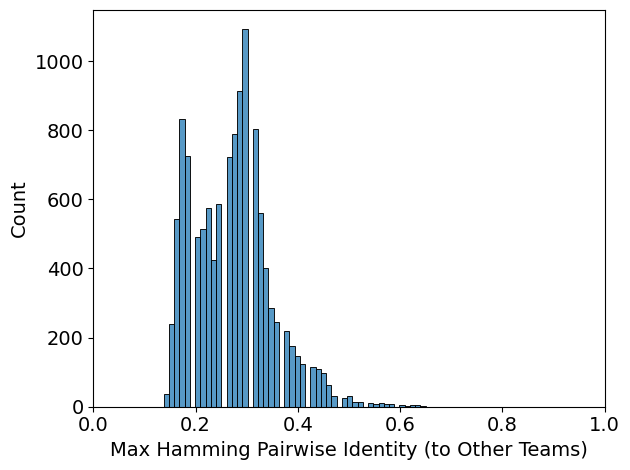

In [ ]:
# Histograms
plt.figure()
sns.histplot(df["max_pident_within_team"], bins=50)
plt.xlabel("Max Hamming Pairwise Identity (Within Team)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('../results/pident/max_str_ident_within_team_histogram.png', dpi=300)

plt.figure()
sns.histplot(df["max_pident_cross_team"], bins=50)
plt.xlabel("Max Hamming Pairwise Identity (to Other Teams)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('../results/pident/max_str_ident_cross_team_histogram.png', dpi=300)

# Summary stats
print("Hamming identity:")
print(f"Within-team max:   {df['max_pident_within_team'].max()}")
print(f"Within-team min:   {df['max_pident_within_team'].min()}")
print(f"Within-team mean:  {df['max_pident_within_team'].mean()}")
print(f"Within-team median:{df['max_pident_within_team'].median()}")

print(f"Cross-team max:    {df['max_pident_cross_team'].max()}")
print(f"Cross-team min:    {df['max_pident_cross_team'].min()}")
print(f"Cross-team mean:   {df['max_pident_cross_team'].mean()}")
print(f"Cross-team median: {df['max_pident_cross_team'].median()}")


In [4]:
# -------------------------------------------------------------------
# 1. Load alignments
# -------------------------------------------------------------------
tsv_path = "../data/individual/mmseqs/all_vs_all.tsv"
cols = ["query", "target", "pident", "alnlen", "qlen", "tlen", "qcov", "tcov", "evalue"]
df_mm = pd.read_csv(tsv_path, sep="\t", header=None, names=cols)

for c in ["pident", "alnlen", "qlen", "tlen", "qcov", "tcov", "evalue"]:
    df_mm[c] = pd.to_numeric(df_mm[c], errors="coerce")

# ---------------------------------------------------------
# 2. Parse sequence id and team from headers
# ---------------------------------------------------------
all_labels = pd.Index(df_mm["query"].unique()).union(df_mm["target"].unique())

label_series = pd.Series(all_labels, name="label")
label_token = label_series.str.split(" ", n=1, expand=True)[0]
parts = label_token.str.split("|", n=1, expand=True)
id_part = parts[0]
group_part = parts[1].fillna("NA")

label_map = pd.DataFrame({
    "label": all_labels,
    "global_id": id_part.values,
    "group": group_part.values
}).set_index("label")

df_mm = df_mm.join(
    label_map.rename(columns={"global_id": "query_id", "group": "query_group"}),
    on="query",
)
df_mm = df_mm.join(
    label_map.rename(columns={"global_id": "target_id", "group": "target_group"}),
    on="target",
)

# ---------------------------------------------------------
# 3. Filter and compute
# ---------------------------------------------------------
# keep reasonably aligned hits (adjust thresholds if you want)
df_mm = df_mm[(df_mm["qcov"] >= 0.3) & (df_mm["tcov"] >= 0.3)]
df_mm = df_mm[df_mm["query_id"] != df_mm["target_id"]]

# within-team and cross-team hits
within = df_mm[df_mm["query_group"] == df_mm["target_group"]]
cross = df_mm[df_mm["query_group"] != df_mm["target_group"]]

max_within_team = within.groupby("query_id")["pident"].max().rename("max_pident_within_team")
max_cross_team = cross.groupby("query_id")["pident"].max().rename("max_pident_cross_team")

# meta info (one row per id)
seq_meta = (
    label_map.reset_index(drop=False)[["global_id", "group"]]
    .drop_duplicates("global_id")
    .set_index("global_id")
)

out = seq_meta.join(max_within_team).join(max_cross_team)
out[["max_pident_within_team", "max_pident_cross_team"]] = out[
    ["max_pident_within_team", "max_pident_cross_team"]
].fillna(0.0)

out = out.reset_index().rename(columns={"index": "global_id", "group": "seq_group"})

out["global_id"] = out["global_id"].map(int)
# convert from percent to fraction
out["max_pident_within_team"] = out["max_pident_within_team"].map(lambda x: float(x) / 100)
out["max_pident_cross_team"] = out["max_pident_cross_team"].map(lambda x: float(x) / 100)
out = out.sort_values(by="global_id")
out.to_csv("../data/individual/max_pairwise_identities_mmseqs.csv", index=False)

MMseqs2 alignment identity:
Within-team max:   1.0
Within-team min:   0.0
Within-team mean:  0.622482
Within-team median:0.6945
Cross-team max:    0.985
Cross-team min:    0.0
Cross-team mean:   0.07382266666666668
Cross-team median: 0.0
Number of sequences with >95% identity to other teams: 0.2005


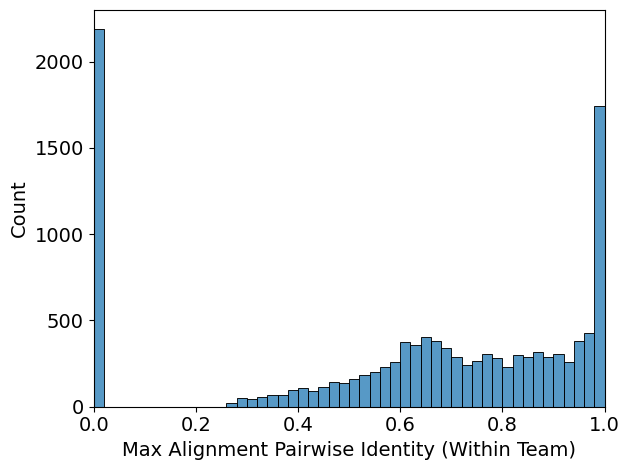

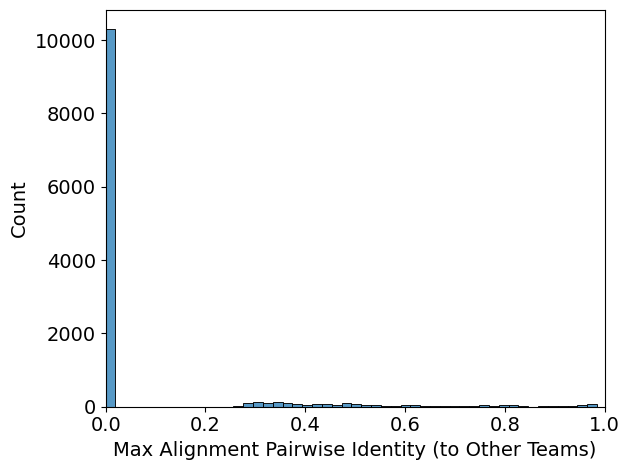

In [9]:
plt.figure()
sns.histplot(out["max_pident_within_team"], bins=50)
plt.xlabel("Max Alignment Pairwise Identity (Within Team)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('../results/pident/max_seq_ident_within_team_histogram.png', dpi=300)

plt.figure()
sns.histplot(out["max_pident_cross_team"], bins=50)
plt.xlabel("Max Alignment Pairwise Identity (to Other Teams)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('../results/pident/max_seq_ident_cross_team_histogram.png', dpi=300)

print("MMseqs2 alignment identity:")
print(f"Within-team max:   {out['max_pident_within_team'].max()}")
print(f"Within-team min:   {out['max_pident_within_team'].min()}")
print(f"Within-team mean:  {out['max_pident_within_team'].mean()}")
print(f"Within-team median:{out['max_pident_within_team'].median()}")

print(f"Cross-team max:    {out['max_pident_cross_team'].max()}")
print(f"Cross-team min:    {out['max_pident_cross_team'].min()}")
print(f"Cross-team mean:   {out['max_pident_cross_team'].mean()}")
print(f"Cross-team median: {out['max_pident_cross_team'].median()}")

# print # of seqs with >0.90 identity cross-team
num_high_ident = (out["max_pident_within_team"] >= 0.95).sum()
print(f"Number of sequences with >95% identity to other teams: {num_high_ident / 12000}")